# Stage 1 — 20x soma/process segmentation

A start-to-finish, VS Code-friendly workflow: resolve only approved motion-corrected acquisitions, build a structural reference from odor-window frames sampled throughout the session, curate somas before detecting processes, curate missing ridge skeletons, group mixed soma/process ROIs, and optionally extract traces.

## 1. Setup — approved acquisitions from a local database snapshot

In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import sys
from pathlib import Path
import time
import numpy as np

for name in (
    "ODYN_ANALYSIS_ROOT",
    "ODYN_IMAGING_ROOT",
    "ODYN_SCRATCH_ROOT",
):
    print(name, "=", os.environ.get(name))

def required_path(variable: str) -> Path:
    value = os.environ.get(variable)

    if not value:
        raise RuntimeError(
            f"{variable} is not configured for this computer."
        )

    path = Path(value).expanduser().resolve()

    if not path.exists():
        raise FileNotFoundError(f"{variable} points to missing path: {path}")

    return path


# Machine-specific locations come from environment variables.
ANALYSIS_ROOT = required_path("ODYN_ANALYSIS_ROOT")
MAIN = required_path("ODYN_IMAGING_ROOT")

SCRATCH = Path(
    os.environ.get(
        "ODYN_SCRATCH_ROOT",
        str(Path.home() / "odyn_scratch"),
    )
).expanduser().resolve()

SCRATCH.mkdir(parents=True, exist_ok=True)

# Allow importing the analysis package without depending on notebook cwd.
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))

from analysis.session.devshim import LocalGroup
from analysis.seg_20x import (
    Segmentation20xState,
    build_reference_images,
    resolve_approved_group,
)
from analysis.seg_20x.gui import launch

GROUP_ID = 175
MANIPULATION = "ketxyl"
REFERENCE_FRAMES_PER_TRIAL = 3
REFERENCE_STRUCTURAL_PERCENTILE = 75
PORTABLE_MASK_BUNDLE = None

LIVE_DB = MAIN / ".odyn" / "odyn.db"
SNAPSHOT = SCRATCH / "odyn_snapshot.db"

assert LIVE_DB.is_file(), f"Database not found: {LIVE_DB}"

group = LocalGroup(
    LIVE_DB,
    MAIN,
    snapshot_to=SNAPSHOT,
    refresh=True,
)

print("database snapshot:", json.dumps(group.snapshot, indent=2))

inputs = resolve_approved_group(group, GROUP_ID)
print(json.dumps(inputs.summary(), indent=2))

import bokeh.plotting as bpl

def vscode_url(port):
    if port is None:
        return "*"
    return f"http://localhost:{port}/"

if not hasattr(bpl, "_odyn_original_show"):
    bpl._odyn_original_show = bpl.show

def vscode_show(obj, *args, **kwargs):
    if callable(obj):
        kwargs.setdefault("notebook_url", vscode_url)
        kwargs.setdefault("port", 5007)

    return bpl._odyn_original_show(obj, *args, **kwargs)

bpl.show = vscode_show

print("Bokeh configured for VS Code port 5007")


ODYN_ANALYSIS_ROOT = /home/users/mosse/repos/ODyn-analysis
ODYN_IMAGING_ROOT = /home/groups/MossLab/ImagingData
ODYN_SCRATCH_ROOT = /home/groups/MossLab/PythonCode/Python/odyn_scratch/mosse
database snapshot: {
  "ok": true,
  "method": "raw_copy",
  "reason": null,
  "attempts": 1,
  "seconds": 1.535,
  "size_mb": 38.9,
  "restarts": 0,
  "steps": 1,
  "mb_per_s": 25.3,
  "source_mtime": 1787469213.6762826,
  "source_changed": false,
  "validated": "quick_check",
  "reused_previous": false
}
{
  "group_id": 175,
  "exp_ids": [
    175
  ],
  "exp_names": [
    "20260706_m442_e1"
  ],
  "n_approved_acquisitions": 182,
  "frame_rate": 12.8619,
  "shape_px": [
    1200,
    2000
  ],
  "n_frames": 260,
  "um_per_px": 0.5,
  "approved_only": true
}
Bokeh configured for VS Code port 5007


The resolver has no directory fallback: only `mcor_files.approved == 1` is eligible. It does not require trial rows, so acquisition-only groups such as 198 resolve through the same path.

## 2. Build or load local reference images

In [2]:
from analysis.session.resolve import resolve_group
reference_session = resolve_group(
    group, group_id=GROUP_ID, manipulation=MANIPULATION, approved_only=True,
)
reference_dir = SCRATCH / 'seg_20x' / f'group{GROUP_ID}'
reference_dir.mkdir(parents=True, exist_ok=True)
reference_h5 = reference_dir / (
    f'reference_session_odor_windows_{REFERENCE_FRAMES_PER_TRIAL}frames_per_trial_'
    f'p{REFERENCE_STRUCTURAL_PERCENTILE:g}_structural_only.h5'
)

if reference_h5.exists():
    import h5py
    with h5py.File(reference_h5, 'r') as cached:
        reference = {name: cached['images'][name][:] for name in cached['images']}
        reference_meta = json.loads(cached.attrs['metadata_json'])
    print('reference cache HIT:', reference_h5)
else:
    t0 = time.time()
    reference, reference_meta = build_reference_images(
        reference_session.paths, odor_on_frames=reference_session.odor_on_frames,
        odor_off_frames=reference_session.odor_off_frames,
        frames_per_trial=REFERENCE_FRAMES_PER_TRIAL,
        structural_percentile=REFERENCE_STRUCTURAL_PERCENTILE,
    )
    import h5py
    with h5py.File(reference_h5, 'w') as cached:
        images = cached.create_group('images')
        for name, image in reference.items():
            images.create_dataset(name, data=image, compression='gzip')
        cached.attrs['metadata_json'] = json.dumps(reference_meta)
    print(f'reference cache MISS: session odor windows read in {time.time()-t0:.1f}s')
print(json.dumps(reference_meta, indent=2))

reference cache HIT: /home/groups/MossLab/PythonCode/Python/odyn_scratch/mosse/seg_20x/group175/reference_acq16133_120frames.npz
{
  "movie_path": "/home/groups/MossLab/ImagingData/20260706/m442/e1/processed/mcor/20260706_m442_e1_00001_mcor.tif",
  "frame_start": 70,
  "frame_stop": 190,
  "n_frames": 120,
  "structural_sigma_px": 0.8,
  "correlation_sigma_px": 0.7,
  "correlation": {
    "n_blocks": 1,
    "n_frames": 120,
    "centered_each_block": true
  }
}


Reference construction and all tuning are local. Frames are sampled from odor windows throughout the session and first averaged within trial. The structural reference is the configurable upper percentile across those trial means (75th by default), so dim anesthetized trials do not wash out processes visible while awake. Sampled acquisition/frame identities and the percentile are stored inside the HDF5 cache. No reference correlation image is calculated; correlation used later for ROI grouping comes from the extracted canonical traces. The GUI never rereads a TIFF.

## 3. Ordered segmentation and curation GUI

In [ ]:
ROUND = SCRATCH / 'seg_20x' / f'group{GROUP_ID}' / 'curated_20x_rois.h5'
if ROUND.exists():
    state = Segmentation20xState.load(ROUND)
    print(f'Resuming saved round in phase {state.phase!r}')
else:
    state = Segmentation20xState(
        reference['structural'],
        soma_params={'dog_threshold': 0.12},
        process_params={'global_ridge_pctl': 70.0, 'adaptive_block_px': 11},
    )
gui = launch(save_path=ROUND, state=state)


Resuming saved round in phase 'group'


ERROR:tornado.application:Uncaught exception GET /ws?id=05ec8b9b-44d6-4e65-8977-f10a42a5e960&parentId=1&origin=078754f2-5f12-4292-b43e-200d36396fd2&swVersion=6&extensionId=&platform=electron&vscode-resource-base-authority=vscode-resource.vscode-cdn.net&parentOrigin=vscode-file%3A%2F%2Fvscode-app&remoteAuthority=ssh-remote%2Barc-interactive&purpose=notebookRenderer (::1)
HTTPServerRequest(protocol='http', host='localhost:5007', method='GET', uri='/ws?id=05ec8b9b-44d6-4e65-8977-f10a42a5e960&parentId=1&origin=078754f2-5f12-4292-b43e-200d36396fd2&swVersion=6&extensionId=&platform=electron&vscode-resource-base-authority=vscode-resource.vscode-cdn.net&parentOrigin=vscode-file%3A%2F%2Fvscode-app&remoteAuthority=ssh-remote%2Barc-interactive&purpose=notebookRenderer', version='HTTP/1.1', remote_ip='::1')
Traceback (most recent call last):
  File "/home/users/mosse/.local/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.o

The five phases are enforced: **tune somas → curate somas → tune processes → curate processes → group ROIs**. Cyan is soma, magenta is process, and yellow is the current group selection or ridge being drawn. Save writes one portable HDF5 bundle holding the curated masks, the detector output they were curated from, the reference images, the parameters, the edits, the ROI table, and the groups.


## 4. Inspect and publish the saved round

When a local GUI round exists, this cell atomically publishes it to the shared session output directory as a portable mask HDF5, then inspects the published copy. On another computer, where the local scratch round is absent, it automatically discovers the newest published bundle. Set `PORTABLE_MASK_BUNDLE` only to override that behavior with a specific file.

In [4]:
import shutil
from analysis.session.store import session_filename

server_output = reference_session.output_dir
server_output.mkdir(parents=True, exist_ok=True)
published_target = server_output / session_filename(
    group_id=reference_session.group_id, exp_name=reference_session.exp_name,
    kind='20x_masks', suffix='.h5',
)
published = sorted(server_output.glob(f'group{GROUP_ID}_*_20x_masks_processed_*.h5'))
if PORTABLE_MASK_BUNDLE is not None:
    bundle_path = Path(PORTABLE_MASK_BUNDLE)
elif ROUND.exists():
    partial = published_target.with_suffix(published_target.suffix + '.partial')
    shutil.copyfile(ROUND, partial)
    partial.replace(published_target)
    bundle_path = published_target
    print('published portable mask bundle:', bundle_path)
elif published:
    bundle_path = published[-1]
else:
    raise FileNotFoundError(
        'No local GUI round or published portable mask bundle was found. '
        'Save from the GUI or set PORTABLE_MASK_BUNDLE.'
    )
if not bundle_path.exists():
    raise FileNotFoundError(f'Portable mask bundle not found: {bundle_path}')

import h5py
with h5py.File(bundle_path, 'r') as saved:
    soma_labels = saved['masks/soma'][:]
    process_labels = saved['masks/process'][:]
    reference = {name: saved['images'][name][:] for name in saved['images']}
    round_config = json.loads(saved.attrs['config_json'])
print('portable mask bundle:', bundle_path)
print(json.dumps(round_config['summary'], indent=2))


portable mask bundle: /home/groups/MossLab/PythonCode/Python/odyn_scratch/mosse/seg_20x/group175/curated_20x_rois.h5
{
  "phase": "group",
  "n_somas": 236,
  "n_processes": 1348,
  "soma_deleted": 34,
  "soma_added": 80,
  "process_deleted": 0,
  "process_added": 0,
  "n_groups": 0,
  "n_grouped_rois": 0
}


## 5. Finalize masks and traces in the standard 10x session format

In [5]:
RUN_EXTRACTION = True  # set True only after approving the saved masks
from analysis.session.resolve import resolve_group
from analysis.session.finalize import finalize_session, verify, mask_hash

# Reopen the published bundle here so extraction cannot accidentally use
# masks left in memory from an earlier GUI or inspection run.
if not bundle_path.exists():
    raise FileNotFoundError(f'Portable mask bundle not found: {bundle_path}')
import h5py
with h5py.File(bundle_path, 'r') as saved:
    soma_labels = saved['masks/soma'][:]
    process_labels = saved['masks/process'][:]
    reference = {'structural': saved['images/structural'][:]}
    round_config = json.loads(saved.attrs['config_json'])
print('finalizing from portable mask bundle:', bundle_path)

# Give every soma and process a contiguous final ROI id. Keep the mapping
# (including roi_group_id) in parameters_json inside the HDF5 round.
combined = np.zeros_like(soma_labels, dtype=np.int32)
soma_mask = np.zeros_like(combined)
process_mask = np.zeros_like(combined)
roi_manifest = []
next_roi = 1
for roi_type, source_labels, typed_mask in (
    ('soma', soma_labels, soma_mask), ('process', process_labels, process_mask)
):
    for source_id in np.unique(source_labels[source_labels > 0]):
        pixels = source_labels == source_id
        combined[pixels] = next_roi
        typed_mask[pixels] = next_roi
        roi_manifest.append({
            'roi_id': next_roi, 'roi_type': roi_type, 'source_roi_id': int(source_id),
            'roi_group_id': round_config.get('groups', {}).get(f'{roi_type}:{int(source_id)}'),
        })
        next_roi += 1

session = resolve_group(group, group_id=GROUP_ID, manipulation=MANIPULATION, approved_only=True)
existing = verify(session.output_dir)
already_current = existing['status'] == 'ok' and existing['mask_hash'] == mask_hash(combined)
print('existing:', existing['status'], '(current mask)' if already_current else '')

if RUN_EXTRACTION and not already_current:
    result = finalize_session(
        session, combined,
        per_group_masks={'soma': soma_mask, 'process': process_mask},
        images=reference['structural'],
        segmentation_params={
            'workflow': '20x_soma_process',
            'soma': round_config['soma_params'],
            'process': round_config['process_params'],
            'roi_manifest': roi_manifest,
        },
        curation=round_config['curation'],
        full_acquisition=True, checkpoint_every=16,
        scratch_dir=SCRATCH, detrend=True,
    )
    print(json.dumps({k: result[k] for k in ('path','mask_png','mask_hash','n_rois')}, indent=2))
    print('verify:', verify(session.output_dir)['status'])
elif RUN_EXTRACTION:
    print('Skipping extraction: the standard HDF5 round already matches this mask.')

finalizing from portable mask bundle: /home/groups/MossLab/PythonCode/Python/odyn_scratch/mosse/seg_20x/group175/curated_20x_rois.h5
existing: ok (current mask)
Skipping extraction: the standard HDF5 round already matches this mask.


The processed HDF5 contains the final masks and traces; 20x finalization does not write a `.mat` sidecar. MATLAB reverses HDF5 array dimensions, so restore the Python axis order when reading:

```matlab
file = "group..._processed_YYYYMMDD.h5";
labels = h5read(file, "/masks/labels").';
somas = h5read(file, "/masks/soma").';
processes = h5read(file, "/masks/process").';
roi = permute(h5read(file, "/traces/roi"), [3 2 1]); % ROI × trial × frame
time_s = h5read(file, "/traces/time_s");
```


## 6. Group ROIs by proximity and correlation

Grouping uses smoothed ΔF/F₀ from the 4-second odor period and 4 seconds afterward, without odor averaging. Candidate pairs must be spatially close and pass the best correlation at −1, 0, or +1 frame lag; each group may contain at most one soma.


1584 ROI traces from group175_20260706_m442_e1_processed_20260822.h5 (detrended)
pair_type   process-process  process-soma  soma-soma
gap_bin_um                                          
0.0                   0.745           NaN      0.767
1.0                   0.737         0.744      0.642
2.0                   0.721         0.704      0.591
3.0                   0.699         0.695      0.620
4.0                   0.691         0.592      0.618
5.0                   0.684         0.634      0.549
6.0                   0.679         0.604      0.718
7.0                   0.664         0.617      0.683
8.0                   0.648         0.585      0.736
9.0                   0.655         0.635      0.673
10.0                  0.652         0.593      0.744
11.0                  0.641         0.603      0.512
12.0                  0.650         0.592      0.587
13.0                  0.642         0.594      0.699
14.0                  0.634         0.594      0.695
15.0              

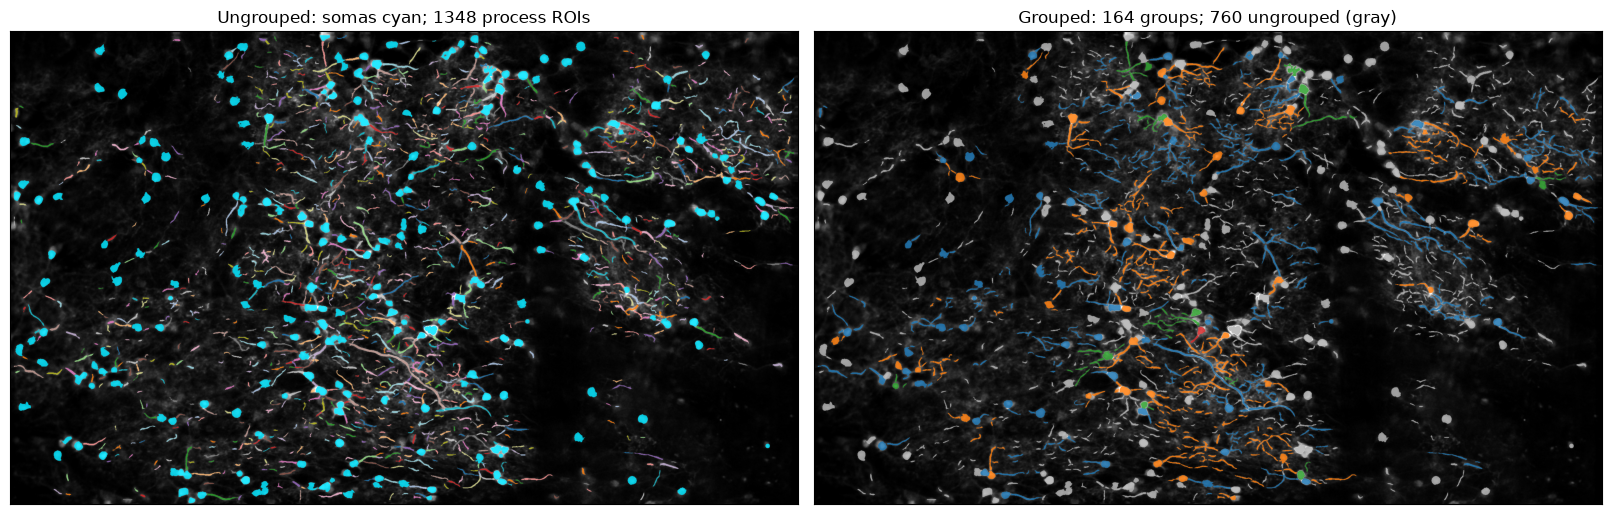

In [6]:
import matplotlib.pyplot as plt

from analysis.session.store import read_session
from analysis.seg_20x.grouping import (
    GROUPING_DEFAULTS, group_rois, pairwise_gaps, proximity_correlation_profile,
    roi_index_image, traces_from_round,
)

GROUPING = {'max_gap_um': 8.0, 'min_correlation': 0.75, 'max_lag_frames': 1}

round_h5 = sorted(session.output_dir.glob(f'group{GROUP_ID}_*_processed_*.h5'))[-1]
parameters = read_session(round_h5)['attrs']['parameters_json']
roi_manifest = parameters['segmentation']['roi_manifest']
traces, trace_source = traces_from_round(round_h5, roi_manifest)
print(f'{len(traces)} ROI traces from {round_h5.name} ({trace_source})')

# The control comes first: correlation that dies within a micron of the PSF
# means the links below are adjacency, not connectivity.
profile = proximity_correlation_profile(
    soma_labels, process_labels, traces, um_per_px=inputs.um_per_px, params=GROUPING)
print(profile.pivot(index='gap_bin_um', columns='pair_type', values='correlation').round(3))

groups, links = group_rois(
    soma_labels, process_labels, traces, um_per_px=inputs.um_per_px, params=GROUPING)
soma_count = {}
for (kind, _), gid in groups.items():
    soma_count[gid] = soma_count.get(gid, 0) + (kind == 'soma')
print(f'{len(soma_count)} groups over {len(groups)} ROIs '
      f'({len(traces) - len(groups)} left ungrouped); '
      f'{sum(n == 0 for n in soma_count.values())} hold no soma')
assert max(soma_count.values(), default=0) <= 1
print(links.status.value_counts().to_string())
print(links[links.linked].head(20).to_string(index=False))


# Compare individual ROIs with the final group assignments.
roi_keys = [
    *(('soma', int(i)) for i in np.unique(soma_labels[soma_labels > 0])),
    *(('process', int(i)) for i in np.unique(process_labels[process_labels > 0])),
]

def pixels_for(key):
    kind, roi_id = key
    labels = soma_labels if kind == 'soma' else process_labels
    return labels == roi_id

# Reorder tab20 so successive entries differ strongly instead of alternating
# between dark and light versions of the same hue.
palette_order = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18,
                 1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
palette = [plt.cm.tab20(i / 19) for i in palette_order]
alpha = 0.85

# Left: one soma color; a distinct cycling color for each process ROI.
ungrouped_rgba = np.zeros((*soma_labels.shape, 4), dtype=float)
ungrouped_rgba[soma_labels > 0] = (0.0, 0.9, 1.0, alpha)
process_keys = [key for key in roi_keys if key[0] == 'process']
for index, key in enumerate(process_keys):
    color = palette[index % len(palette)]
    ungrouped_rgba[pixels_for(key)] = (*color[:3], alpha)

# Right: greedily color the group-neighbor graph so spatially adjacent groups
# do not share a color. Ungrouped ROIs remain gray.
group_ids = sorted(set(groups.values()), key=repr)
neighbors = {group_id: set() for group_id in group_ids}
index_image, indexed_keys = roi_index_image(soma_labels, process_labels)
near_pairs = pairwise_gaps(
    index_image, len(indexed_keys), GROUPING['max_gap_um'] / inputs.um_per_px
)
for left, right in near_pairs:
    group_left = groups.get(indexed_keys[left])
    group_right = groups.get(indexed_keys[right])
    if group_left is not None and group_right is not None and group_left != group_right:
        neighbors[group_left].add(group_right)
        neighbors[group_right].add(group_left)

color_index = {}
for group_id in sorted(group_ids, key=lambda value: (-len(neighbors[value]), repr(value))):
    used = {color_index[other] for other in neighbors[group_id] if other in color_index}
    color_index[group_id] = next(index for index in range(len(palette)) if index not in used)

grouped_rgba = np.zeros((*soma_labels.shape, 4), dtype=float)
for key in roi_keys:
    group_id = groups.get(key)
    color = ((0.7, 0.7, 0.7, 1.0) if group_id is None
             else palette[color_index[group_id]])
    grouped_rgba[pixels_for(key)] = (*color[:3], alpha)

structural = reference['structural']
lo, hi = np.percentile(structural[np.isfinite(structural)], (1, 99.5))
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
for ax, overlay, title in (
    (axes[0], ungrouped_rgba,
     f'Ungrouped: somas cyan; {len(process_keys)} process ROIs'),
    (axes[1], grouped_rgba,
     f'Grouped: {len(group_ids)} groups; '
     f'{len(roi_keys) - len(groups)} ungrouped (gray)'),
):
    ax.imshow(structural, cmap='gray', vmin=lo, vmax=hi)
    ax.imshow(overlay)
    ax.set(title=title, xticks=[], yticks=[])

group_figure = round_h5.with_name(round_h5.stem + '_groups.png')
fig.savefig(group_figure, dpi=160, bbox_inches='tight')
print(f'grouping figure: {group_figure}')


## 7. Group-aware 20x trace QC

Every unassigned ROI is retained as a singleton analysis unit. Within assigned groups, raw ROI fluorescence is weighted by ROI pixel count before the canonical detrend and z-score. Each trial is centred and scaled using its own immediate four-second pre-odor baseline. Responses remain continuous: mean and positive/negative peak z scores are summarized during odor and during the four seconds after odor offset. Session- and block-pooled baseline SDs remain diagnostics only. The three displays use whole units, soma pixels only, and process pixels only.

In [ ]:
from analysis.seg_20x.qc import qc_20x

qc = qc_20x(
    round_h5,
    # Use the trace-derived assignments above; ROIs absent from this dict
    # are deliberately retained as singleton units.
    groups=groups,
    structural=reference['structural'],
)
print(json.dumps(qc, indent=2))

[20x QC     0.0s] loading extracted round group175_20260706_m442_e1_processed_20260822.h5
[20x QC     2.0s] groups: pixel-weighting raw fluorescence
[20x QC     2.2s] groups: detrending 924 analysis units
[20x QC     3.0s] groups: calculating dF/F and trial response z-scores
[20x QC    33.7s] groups: fitting fixed time-resolved PC1
[20x QC    34.8s] groups: PC1 power iteration 1/30
[20x QC    37.2s] groups: PC1 power iteration 5/30
[20x QC    39.9s] groups: PC1 power iteration 10/30
[20x QC    41.0s] trace atlas groups: page 1/39
[20x QC    44.6s] trace atlas groups: page 2/39
[20x QC    48.1s] trace atlas groups: page 3/39
[20x QC    51.6s] trace atlas groups: page 4/39
[20x QC    55.1s] trace atlas groups: page 5/39
[20x QC    58.7s] trace atlas groups: page 6/39
[20x QC    62.4s] trace atlas groups: page 7/39
[20x QC    65.7s] trace atlas groups: page 8/39
[20x QC    69.5s] trace atlas groups: page 9/39
[20x QC    72.8s] trace atlas groups: page 10/39
[20x QC    76.8s] trace atlas g

/home/users/mosse/repos/ODyn-analysis/analysis/session/responders.py:1076: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([f"{abs(v):.0%}" for v in labels])
/home/users/mosse/repos/ODyn-analysis/analysis/session/responders.py:1076: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([f"{abs(v):.0%}" for v in labels])
/home/users/mosse/repos/ODyn-analysis/analysis/session/responders.py:1076: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([f"{abs(v):.0%}" for v in labels])
/home/users/mosse/repos/ODyn-analysis/analysis/session/responders.py:1076: UserWarning: set_ticklabels() should onl

[20x QC   396.4s] rendering SNR distributions
[20x QC   396.6s] writing trial-level PC1 scores
[20x QC   396.6s] complete in 396.6 s
{
  "trace_atlas": {
    "groups": [
      "/home/groups/MossLab/ImagingData/20260706/m442/e1/processed/python/group175_20260706_m442_e1_processed_20260822_traceatlas_groups_p01.png",
      "/home/groups/MossLab/ImagingData/20260706/m442/e1/processed/python/group175_20260706_m442_e1_processed_20260822_traceatlas_groups_p02.png",
      "/home/groups/MossLab/ImagingData/20260706/m442/e1/processed/python/group175_20260706_m442_e1_processed_20260822_traceatlas_groups_p03.png",
      "/home/groups/MossLab/ImagingData/20260706/m442/e1/processed/python/group175_20260706_m442_e1_processed_20260822_traceatlas_groups_p04.png",
      "/home/groups/MossLab/ImagingData/20260706/m442/e1/processed/python/group175_20260706_m442_e1_processed_20260822_traceatlas_groups_p05.png",
      "/home/groups/MossLab/ImagingData/20260706/m442/e1/processed/python/group175_20260706_m44

ERROR:tornado.application:Uncaught exception GET /ws?id=05ec8b9b-44d6-4e65-8977-f10a42a5e960&parentId=1&origin=078754f2-5f12-4292-b43e-200d36396fd2&swVersion=6&extensionId=&platform=electron&vscode-resource-base-authority=vscode-resource.vscode-cdn.net&parentOrigin=vscode-file%3A%2F%2Fvscode-app&remoteAuthority=ssh-remote%2Barc-interactive&purpose=notebookRenderer (::1)
HTTPServerRequest(protocol='http', host='localhost:5007', method='GET', uri='/ws?id=05ec8b9b-44d6-4e65-8977-f10a42a5e960&parentId=1&origin=078754f2-5f12-4292-b43e-200d36396fd2&swVersion=6&extensionId=&platform=electron&vscode-resource-base-authority=vscode-resource.vscode-cdn.net&parentOrigin=vscode-file%3A%2F%2Fvscode-app&remoteAuthority=ssh-remote%2Barc-interactive&purpose=notebookRenderer', version='HTTP/1.1', remote_ip='::1')
Traceback (most recent call last):
  File "/home/users/mosse/.local/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.o